# 04 — CNN Theory: Convolution, Receptive Field, Pooling
**Phase 3 · Week 9 · Thursday · Jun 4 2026 · Remote**

## What We Cover Today
| Topic | Core Idea |
|---|---|
| Convolution Operation | Sliding a learned filter over an image to detect local patterns |
| Stride & Padding | Control output size and preserve spatial resolution |
| Output Size Formula | (W − F + 2P) / S + 1 |
| Receptive Field | How large a region of the input influences one output neuron |
| Feature Maps | Each filter produces one feature map — depth = number of filters |
| Pooling Layers | Spatial downsampling — MaxPool keeps strongest activations |
| Parameter Count | How many weights a conv layer has vs a fully-connected layer |
| CNN from Scratch | Build a working conv net in pure PyTorch |

---

## 1 · The Convolution Operation

In CNNs, "convolution" is technically **cross-correlation**: slide a small filter (kernel) across the input, computing a dot product at each position.

For a 2D input I and filter K of size F×F:
```
(I ★ K)[i, j] = Σ_m Σ_n  I[i+m, j+n] · K[m, n]
```

**Why convolution?**
- **Local connectivity** — each output only sees a small neighbourhood (F×F) of the input, not the whole image
- **Parameter sharing** — the same filter is applied everywhere → far fewer parameters than fully-connected
- **Translation equivariance** — a pattern detector works the same regardless of where the pattern appears

**Convolution layer input/output shapes:**
```
Input  : (batch, C_in,  H,   W)
Filter : (C_out, C_in,  F,   F)      ← C_out filters, each of size C_in × F × F
Output : (batch, C_out, H',  W')
```

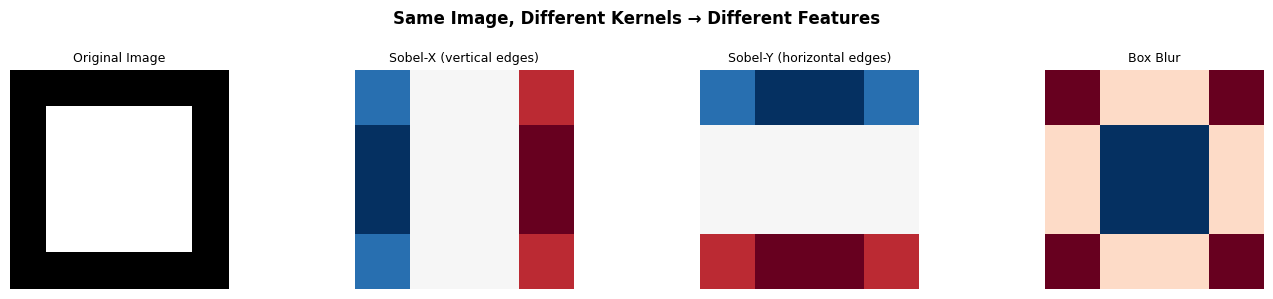

Convolution output shape: input(6,6), kernel(3,3) → output (4, 4)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# ── Manual 2D convolution (no padding, stride=1) ──────────────────────────
def conv2d_manual(image, kernel):
    H, W   = image.shape
    F, _   = kernel.shape
    H_out  = H - F + 1
    W_out  = W - F + 1
    output = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            output[i, j] = (image[i:i+F, j:j+F] * kernel).sum()
    return output

# Test with a simple 6×6 image and edge-detect kernel
img = np.array([
    [0,0,0,0,0,0],
    [0,1,1,1,1,0],
    [0,1,1,1,1,0],
    [0,1,1,1,1,0],
    [0,1,1,1,1,0],
    [0,0,0,0,0,0]], dtype=float)

sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float)   # vertical edges
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=float)    # horizontal edges
blur    = np.ones((3,3)) / 9                                      # box blur

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, kern, title in zip(axes[1:],
    [sobel_x, sobel_y, blur],
    ['Sobel-X (vertical edges)', 'Sobel-Y (horizontal edges)', 'Box Blur']):
    result = conv2d_manual(img, kern)
    ax.imshow(result, cmap='RdBu', interpolation='nearest')
    ax.set_title(title, fontsize=9)
    ax.axis('off')
axes[0].imshow(img, cmap='gray', interpolation='nearest')
axes[0].set_title('Original Image', fontsize=9)
axes[0].axis('off')

plt.suptitle("Same Image, Different Kernels → Different Features", fontweight='bold')
plt.tight_layout()
plt.savefig("conv_kernels.png", dpi=120, bbox_inches='tight')
plt.show()
print("Convolution output shape: input(6,6), kernel(3,3) → output", conv2d_manual(img, sobel_x).shape)

---

## 2 · Output Size Formula — Stride & Padding

**Without padding:**
```
H_out = (H_in − F) / S  + 1
W_out = (W_in − F) / S  + 1
```

**With padding P:**
```
H_out = (H_in − F + 2P) / S  + 1
```

**Common cases:**
| Goal | Formula | Example (H=28, F=3) |
|---|---|---|
| Shrink by 1 (same kernel, no pad) | P=0, S=1 | 28→26 |
| Same size (same padding) | P=(F-1)/2, S=1 | 28→28 (P=1) |
| Halve the size | P=0, S=2 | 28→13 |
| Halve with padding | P=1, S=2 | 28→14 |

**Padding types in PyTorch:**
- `padding=0` — no padding (output shrinks)
- `padding=1` — pad 1 zero on each side
- `padding='same'` — auto-compute to keep H/W unchanged (only with stride=1)

In [2]:
def output_size(H_in, F, P, S):
    return (H_in - F + 2*P) // S + 1

# Demo table
print(f"{'H_in':>6} {'F':>4} {'P':>4} {'S':>4} {'H_out':>8}")
print("-" * 32)
configs = [
    (28,3,0,1,"no pad, stride 1"),
    (28,3,1,1,"same pad, stride 1"),
    (28,3,0,2,"no pad, stride 2"),
    (28,3,1,2,"pad 1,  stride 2"),
    (224,3,1,1,"ImageNet, same pad"),
    (224,7,3,2,"AlexNet-style stem"),
]
for H,F,P,S,note in configs:
    out = output_size(H,F,P,S)
    print(f"{H:>6} {F:>4} {P:>4} {S:>4} {out:>8}   ← {note}")

# PyTorch verification
x = torch.randn(1, 1, 28, 28)
conv_same = nn.Conv2d(1, 16, kernel_size=3, padding=1, stride=1)
conv_half = nn.Conv2d(1, 16, kernel_size=3, padding=1, stride=2)
conv_none = nn.Conv2d(1, 16, kernel_size=3, padding=0, stride=1)
print(f"\nPyTorch verification (input 28×28):")
print(f"  padding=1, stride=1 → {conv_same(x).shape[-2:]}")
print(f"  padding=1, stride=2 → {conv_half(x).shape[-2:]}")
print(f"  padding=0, stride=1 → {conv_none(x).shape[-2:]}")

  H_in    F    P    S    H_out
--------------------------------
    28    3    0    1       26   ← no pad, stride 1
    28    3    1    1       28   ← same pad, stride 1
    28    3    0    2       13   ← no pad, stride 2
    28    3    1    2       14   ← pad 1,  stride 2
   224    3    1    1      224   ← ImageNet, same pad
   224    7    3    2      112   ← AlexNet-style stem

PyTorch verification (input 28×28):
  padding=1, stride=1 → torch.Size([28, 28])
  padding=1, stride=2 → torch.Size([14, 14])
  padding=0, stride=1 → torch.Size([26, 26])


---

## 3 · Receptive Field & Parameter Count

### Receptive Field
The receptive field of a neuron is the region of the **original input** that influences its value.

- Layer 1 conv (3×3): receptive field = **3×3**
- Layer 2 conv (3×3): receptive field = **5×5** (each 3×3 region in layer 1 covers 5×5 in input)
- Layer k conv (3×3): receptive field = **2k+1 × 2k+1**

Two stacked 3×3 convs have the same receptive field as one 5×5 conv, but use fewer parameters — this is why VGGNet uses only 3×3 filters.

### Parameter Count

**Convolutional layer:**
```
params = F × F × C_in × C_out  +  C_out (biases)
```

**Fully-connected layer (same coverage):**
```
params = (H × W × C_in)  ×  C_out    ← scales with spatial size!
```

Conv is vastly more efficient because the filter is **shared** across all spatial positions.

In [3]:
# Parameter count comparison
def conv_params(F, C_in, C_out, bias=True):
    return F*F*C_in*C_out + (C_out if bias else 0)

def fc_params(H, W, C_in, C_out, bias=True):
    return H*W*C_in*C_out + (C_out if bias else 0)

print("Parameter Comparison: Covering a 28×28 RGB image")
print("="*55)
layers = [
    (3,  3, 32, "Conv 3×3 → 32 filters"),
    (5,  3, 32, "Conv 5×5 → 32 filters"),
    (7,  3, 32, "Conv 7×7 → 32 filters"),
    (3,  3, 64, "Conv 3×3 → 64 filters"),
]
for F, C_in, C_out, name in layers:
    cp = conv_params(F, C_in, C_out)
    print(f"  {name:30s}: {cp:>8,} params")

print()
print(f"  FC layer (28×28×3 → 32)       : {fc_params(28,28,3,32):>8,} params")
print(f"  FC layer (28×28×3 → 64)       : {fc_params(28,28,3,64):>8,} params")

# Receptive field growth
print("\nReceptive Field Growth (3×3 conv, stride=1, no dilation):")
rf = 1
for layer in range(1, 8):
    rf = rf + 2*(3//2)
    print(f"  After layer {layer}: {rf}×{rf}")

Parameter Comparison: Covering a 28×28 RGB image
  Conv 3×3 → 32 filters         :      896 params
  Conv 5×5 → 32 filters         :    2,432 params
  Conv 7×7 → 32 filters         :    4,736 params
  Conv 3×3 → 64 filters         :    1,792 params

  FC layer (28×28×3 → 32)       :   75,296 params
  FC layer (28×28×3 → 64)       :  150,592 params

Receptive Field Growth (3×3 conv, stride=1, no dilation):
  After layer 1: 3×3
  After layer 2: 5×5
  After layer 3: 7×7
  After layer 4: 9×9
  After layer 5: 11×11
  After layer 6: 13×13
  After layer 7: 15×15


---

## 4 · Pooling Layers

Pooling reduces spatial dimensions **without learnable parameters**:

**MaxPool** — takes the maximum in each window:
```
For 2×2 MaxPool, stride=2:
input:    output:
[1 3]  →  [3]     (max of window)
[2 0]
```

**AvgPool** — takes the mean. Smoother but MaxPool is more common in classification.

**Global Average Pooling (GAP)** — averages each entire feature map to a single value:
```
Input: (batch, C, H, W)  →  Output: (batch, C)
```
GAP replaces the final fully-connected layer in modern architectures (ResNet, MobileNet) — no parameters, very effective.

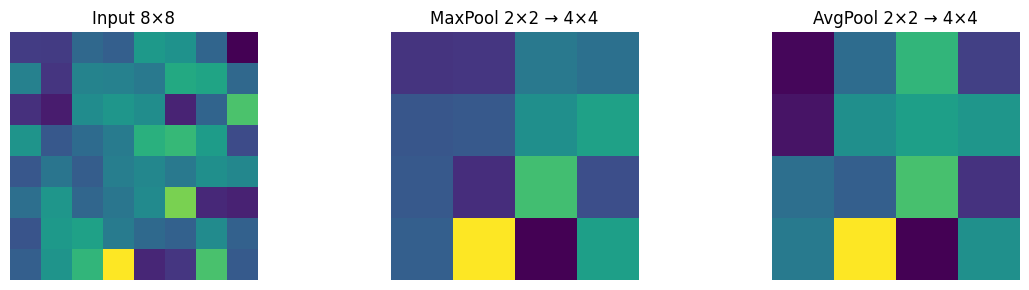

Input  shape : torch.Size([1, 1, 8, 8])
MaxPool shape: torch.Size([1, 1, 4, 4])
AvgPool shape: torch.Size([1, 1, 4, 4])
GAP     shape: torch.Size([1, 1, 1, 1])  ← each channel → single value


In [4]:
# Visualise MaxPool vs AvgPool effect
torch.manual_seed(0)
feat = torch.randn(1, 1, 8, 8)                      # one feature map

maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
avgpool = nn.AvgPool2d(kernel_size=2, stride=2)
gap     = nn.AdaptiveAvgPool2d(1)                    # global average pool → 1×1

out_max = maxpool(feat)
out_avg = avgpool(feat)
out_gap = gap(feat)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(feat[0,0].numpy(), cmap='viridis'); axes[0].set_title(f"Input {feat.shape[-2]}×{feat.shape[-1]}")
axes[1].imshow(out_max[0,0].numpy(), cmap='viridis'); axes[1].set_title(f"MaxPool 2×2 → {out_max.shape[-2]}×{out_max.shape[-1]}")
axes[2].imshow(out_avg[0,0].numpy(), cmap='viridis'); axes[2].set_title(f"AvgPool 2×2 → {out_avg.shape[-2]}×{out_avg.shape[-1]}")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig("pooling_comparison.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"Input  shape : {feat.shape}")
print(f"MaxPool shape: {out_max.shape}")
print(f"AvgPool shape: {out_avg.shape}")
print(f"GAP     shape: {out_gap.shape}  ← each channel → single value")

---

## 5 · CNN from Scratch in PyTorch

A small LeNet-style CNN: 2 conv blocks + 2 FC layers. Covers all components studied today.

Shape trace (batch=4, MNIST-size 1×28×28):
  After Block1 : torch.Size([4, 16, 14, 14])
  After Block2 : torch.Size([4, 32, 7, 7])
  After Classify: torch.Size([4, 10])

Total parameters: 207,018
  (vs FC-only baseline: 101,632 params for same task)


  Epoch  1 loss: 2.3557


  Epoch  4 loss: 2.2993


  Epoch  7 loss: 2.2927


  Epoch 10 loss: 2.2799


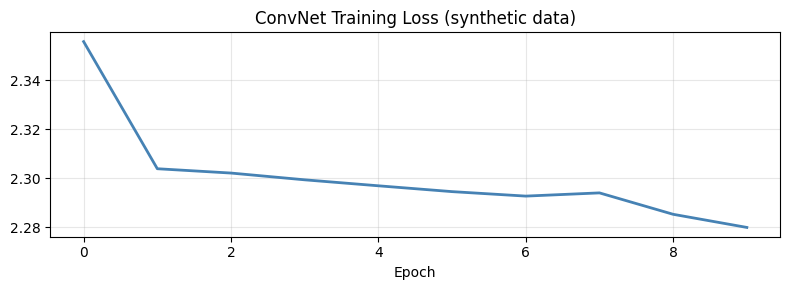

In [5]:
class ConvNet(nn.Module):
    """Small CNN: conv+pool × 2  →  FC × 2  →  softmax"""
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        # Block 1: 1×28×28 → 16×13×13
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),  # 28→28
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                     # 28→14
        )
        # Block 2: 16×14×14 → 32×7×7
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),            # 14→14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                                     # 14→7
        )
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)

model = ConvNet()
x_test = torch.randn(4, 1, 28, 28)

# Trace shapes through the network
print("Shape trace (batch=4, MNIST-size 1×28×28):")
x = x_test
x = model.block1(x);      print(f"  After Block1 : {x.shape}")
x = model.block2(x);      print(f"  After Block2 : {x.shape}")
x = model.classifier(x);  print(f"  After Classify: {x.shape}")

total = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total:,}")
print(f"  (vs FC-only baseline: {1*28*28*128 + 128*10:,} params for same task)")

# Quick training demo on synthetic data
from torch.utils.data import TensorDataset, DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ConvNet().to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
crit  = nn.CrossEntropyLoss()

X_syn = torch.randn(3000, 1, 28, 28)
y_syn = torch.randint(0, 10, (3000,))
loader = DataLoader(TensorDataset(X_syn, y_syn), batch_size=128, shuffle=True)

losses = []
for epoch in range(10):
    model.train(); ep_loss = []
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(Xb), yb)
        loss.backward(); opt.step()
        ep_loss.append(loss.item())
    losses.append(np.mean(ep_loss))
    if epoch % 3 == 0: print(f"  Epoch {epoch+1:2d} loss: {losses[-1]:.4f}")

plt.figure(figsize=(8,3))
plt.plot(losses, 'steelblue', lw=2)
plt.title("ConvNet Training Loss (synthetic data)"); plt.xlabel("Epoch"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("cnn_training.png", dpi=120, bbox_inches='tight'); plt.show()

---

## What I Learned Today

**Convolution** — A filter slides over the input computing dot products at each position. Filters detect local patterns (edges, textures, shapes). Same filter applied everywhere = translation equivariance + very few parameters.

**Output size** — Formula: (H − F + 2P)/S + 1. With padding=1, stride=1 and kernel=3 → output same size as input. With stride=2 → roughly halve the spatial size.

**Receptive field** — Each extra conv layer with 3×3 kernel adds 2 pixels to the receptive field. After 5 layers the receptive field is 11×11 in the original image. Deeper networks see larger context.

**Parameter count** — Conv layer: F×F×C_in×C_out (independent of spatial size). FC layer: H×W×C_in×C_out (grows with image size). A conv layer covering a 28×28 image with 3×3 kernel, 32 filters uses 896 params vs 75,264 for an equivalent FC layer.

**MaxPool** — Downsamples by taking the maximum in each window. 2×2 MaxPool with stride=2 halves both H and W. No learnable parameters.

**Key architecture rule:** Stack (Conv → BN → ReLU → Pool) blocks. Every block roughly doubles C and halves H, W. End with Global Average Pooling → FC → softmax.